In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


path='C:/Users/Nicolas Catz/Documents/OpenBCI_GUI/Recordings/' # specify the path to the folder containing the data file
path='D:\\DATA\\Projets\\M1_EEG_Project\\' # specify the path to the folder containing the data file/

session='data' # specify the name of the session folder

filename='auditory_test.csv' # specify the name of the data file
filename='contamination_test.csv' # specify the name of the data file

# filename='openbci_simulated_N100P200_tab_sans_entete.csv' # specify the name of the data file

data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame  

stimulus=data[13]


C:\Users\Nicolas Catz\AppData\Local\Temp\ipykernel_96796\4030000248.py:18: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame


In [59]:
data

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
1,1.0,-710382.337616,52542.603319,-18417.122175,-38651.977617,-447559.439845,-58376.050994,-58832.652430,-61190.672063,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
2,2.0,-708311.940230,52540.725772,-16746.016353,-38805.936433,-445835.852127,-58490.223705,-59009.678246,-61402.477193,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
3,3.0,-706173.146507,52481.448946,-15196.861648,-38962.309237,-443983.071325,-58662.957986,-59128.410712,-61495.639264,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
4,4.0,-707752.431363,52465.713318,-16526.254001,-38820.688584,-445211.254980,-58585.889171,-58950.759047,-61263.091715,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138884,88.0,-391284.899865,47731.166808,-69663.771351,-21279.575977,-666663.130124,-30229.572085,-35368.685170,-44913.952936,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
138885,89.0,-389271.097096,47880.208240,-67971.386668,-21306.755699,-665008.296371,-30345.711749,-35426.531485,-44891.422378,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
138886,90.0,-390547.739333,47294.592535,-68985.530017,-21225.395349,-666000.535011,-30768.606754,-35327.021519,-44718.598690,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
138887,91.0,-392723.458138,47013.854624,-70768.215748,-21171.482941,-667779.286835,-30739.191859,-35223.309424,-44658.517201,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0


In [60]:
threshold = (stimulus.max() + stimulus.min()) / 2
above = stimulus > threshold

onset_mask = above & ~above.shift(1, fill_value=False)
onsets = stimulus.index[onset_mask]

print(f"Detected {len(onsets)} stimulus onsets at indices: {onsets.tolist()}")

eeg_data=data.iloc[:, 1:9]  # select the EEG data columns (assuming they are in columns 1 to 8)


Detected 157 stimulus onsets at indices: [1767, 2039, 2372, 2654, 2938, 3272, 3550, 3905, 4223, 4516, 4839, 5160, 5474, 5753, 6110, 6410, 6755, 7065, 7424, 7737, 8032, 8383, 8686, 9007, 9277, 9611, 9899, 10210, 10572, 10931, 11216, 11484, 11837, 12167, 12491, 12842, 44172, 46271, 46601, 46897, 47218, 47561, 47891, 48184, 48448, 48773, 49070, 49403, 49760, 50063, 50371, 50696, 50992, 51276, 51563, 51872, 52226, 52557, 52848, 53196, 53543, 53855, 54119, 54398, 54702, 54996, 55356, 55663, 55927, 56231, 56503, 56819, 57168, 57483, 57817, 58132, 58465, 58737, 59038, 59350, 59632, 59951, 60289, 60568, 60912, 61179, 61500, 61773, 62072, 62397, 62705, 62974, 63256, 63565, 63916, 64196, 64482, 64812, 65121, 65483, 65820, 66131, 66443, 66789, 67078, 67390, 67687, 68000, 68361, 68669, 69019, 69326, 69602, 69931, 70267, 70546, 70897, 71197, 71481, 71760, 72080, 72389, 72673, 72996, 73335, 73638, 73982, 74333, 74690, 75037, 75301, 75653, 75931, 76217, 76505, 76846, 77135, 77497, 77851, 78154, 78501

In [ ]:
from scipy.signal import butter, filtfilt, iirnotch

fs = 250
print(f"Fréquence d'échantillonnage estimée : {fs:.2f} Hz")

def bandpass_filter(sig, low=1.0, high=40.0, fs=fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

def notch_filter(sig, freq=50.0, fs=fs, q=30):
    nyq = fs / 2
    b, a = iirnotch(freq / nyq, q)
    return filtfilt(b, a, sig)


Fréquence d'échantillonnage estimée : 250.00 Hz


In [62]:
eeg_data=eeg_data.to_numpy()  # convert the DataFrame to a NumPy array for easier processing
eeg_data=eeg_data.T

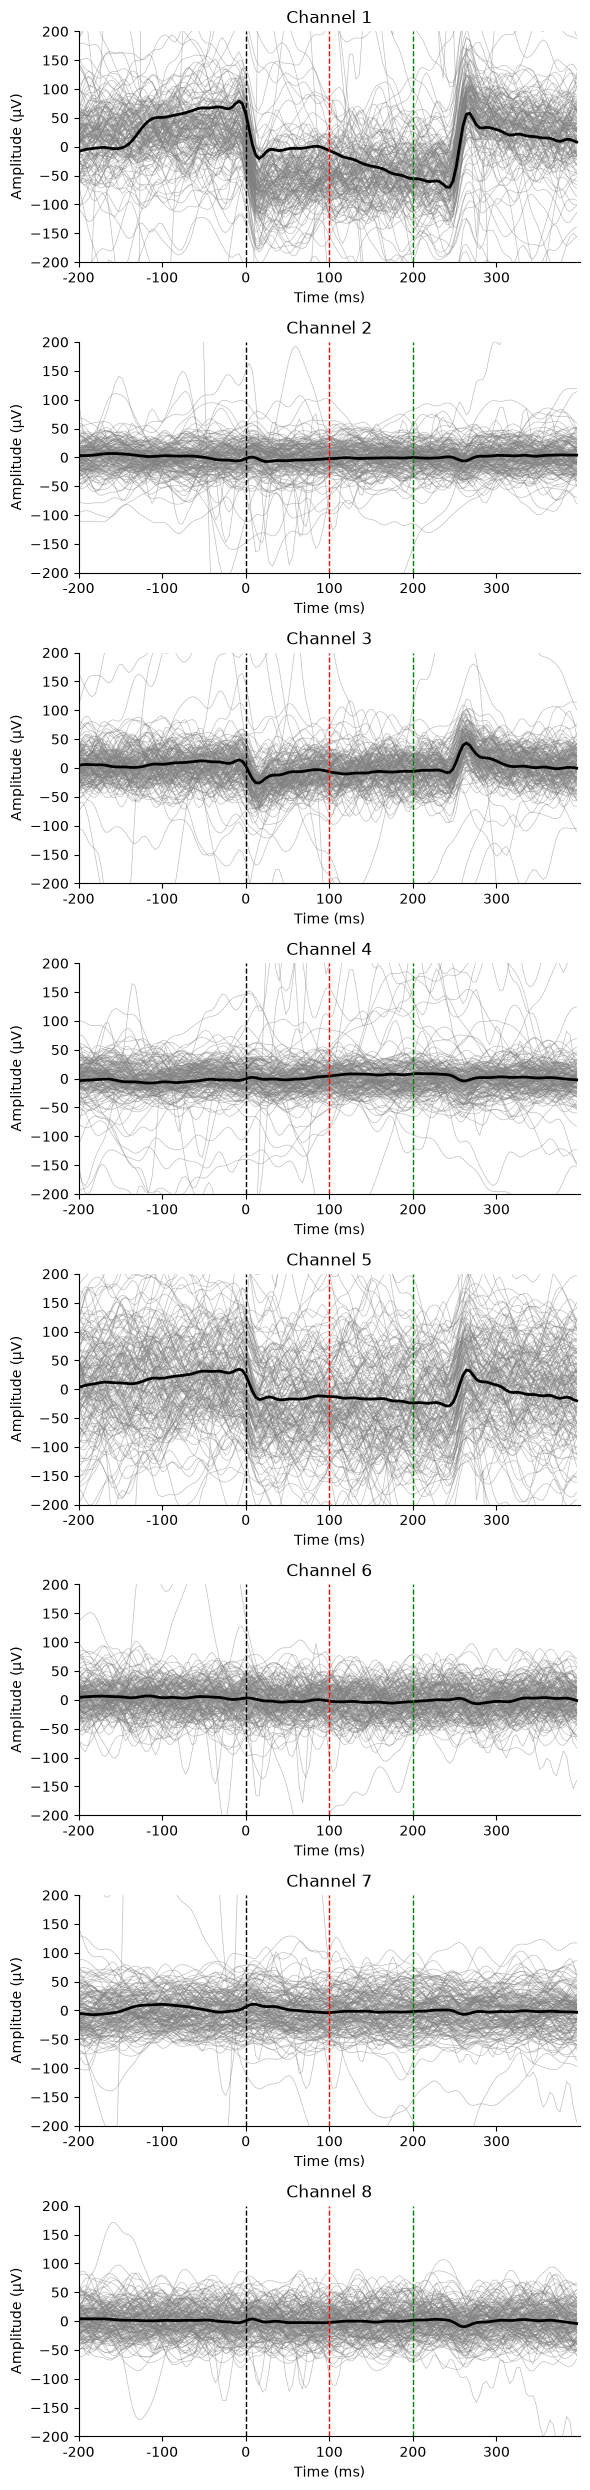

In [63]:
fig,axs=plt.subplots(8,1,figsize=(6,25))

for channel in range(0,8):  # Only process the first channel
    
    raw_signal = eeg_data[channel, :-2]

    eeg_filtered = notch_filter(bandpass_filter(raw_signal))

    pre=50
    post=100
    eegaligned = []
    for time in onsets:
        # print(f"Aligning EEG data for channel {channel} at time {time}")
        eegaligned.append(eeg_filtered[time-pre:time+post])

    axs[channel].plot(np.transpose(eegaligned),'gray', alpha=0.5,lw=0.5)
    axs[channel].plot(np.mean(eegaligned, axis=0), 'k', linewidth=2)
    axs[channel].axvline(50, color='black', linestyle='--', linewidth=1)
    axs[channel].axvline(75, color='red', linestyle='--', linewidth=1)
    axs[channel].axvline(100, color='green', linestyle='--', linewidth=1)
    axs[channel].set_title(f'Channel {channel+1}')
    axs[channel].set_xlabel('Time (ms)')
    axs[channel].set_ylabel('Amplitude (µV)')
    axs[channel].set_xlim(0, 150)
    axs[channel].set_ylim(-200, 200)
    axs[channel].set_xticks([0,25,50, 75, 100, 125], ['-200', '-100', '0', '100', '200', '300'])
    axs[channel].spines['top'].set_visible(False)
    axs[channel].spines['right'].set_visible(False)
plt.tight_layout()  
  